In [1]:
import pandas as pd
df = pd.read_csv("Wholesale customers data.csv")



In [8]:
import pandas as pd

# Read the dataset
df = pd.read_csv("Wholesale customers data.csv")

# Check for missing values
print("Missing values per column:")
print(df.isna().sum())

# Drop rows with missing values (if any)
df = df.dropna()

# Drop Channel and Region columns
df = df.drop(['Channel', 'Region'], axis=1)

print("\nRemaining columns:", df.columns.tolist())
print("\nPreview of cleaned dataset:")
print(df.head())


Missing values per column:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Remaining columns: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

Preview of cleaned dataset:
   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669  9656     7561     214              2674        1338
1   7057  9810     9568    1762              3293        1776
2   6353  8808     7684    2405              3516        7844
3  13265  1196     4221    6404               507        1788
4  22615  5410     7198    3915              1777        5185


In [ ]:


# Choose most important features
selected_features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
     "Detergents_Paper"
]

X = df[selected_features]
y = df["Delicassen"]

print("Selected Features:")
print(X.head())

Selected Features:
   Fresh  Milk  Grocery  Frozen  Detergents_Paper
0  12669  9656     7561     214              2674
1   7057  9810     9568    1762              3293
2   6353  8808     7684    2405              3516
3  13265  1196     4221    6404               507
4  22615  5410     7198    3915              1777


In [ ]:
#Step4 : Preprocessing
# scaling
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("Wholesale customers data.csv")

# Drop missing values (if any)
df = df.dropna()

# Drop Channel and Region columns
df = df.drop(['Channel', 'Region'], axis=1)

# Create the scaler
scaler = StandardScaler()

# Fit and transform the data
scaled_data = scaler.fit_transform(df)

# Convert back to a DataFrame for easier use
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

print("Scaled data (first 5 rows):")
print(df_scaled.head())


Scaled data (first 5 rows):
      Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
0  0.052933  0.523568 -0.041115 -0.589367         -0.043569   -0.066339
1 -0.391302  0.544458  0.170318 -0.270136          0.086407    0.089151
2 -0.447029  0.408538 -0.028157 -0.137536          0.133232    2.243293
3  0.100111 -0.624020 -0.392977  0.687144         -0.498588    0.093411
4  0.840239 -0.052396 -0.079356  0.173859         -0.231918    1.299347


In [ ]:
#Encode
import pandas as pd

# Load the dataset
df = pd.read_csv("Wholesale customers data.csv")

# Drop missing values (if any)
df = df.dropna()

# One-hot encode Channel and Region
df_encoded = pd.get_dummies(df, columns=['Channel', 'Region'], drop_first=True)

print(df_encoded.head())


   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen  Channel_2  \
0  12669  9656     7561     214              2674        1338       True   
1   7057  9810     9568    1762              3293        1776       True   
2   6353  8808     7684    2405              3516        7844       True   
3  13265  1196     4221    6404               507        1788      False   
4  22615  5410     7198    3915              1777        5185       True   

   Region_2  Region_3  
0     False      True  
1     False      True  
2     False      True  
3     False      True  
4     False      True  


In [ ]:
#Dealing with Nan values.
import pandas as pd

# Read the dataset
df = pd.read_csv("Wholesale customers data.csv")

# Check NaN values
print("NaN counts:\n", df.isna().sum())

# Drop missing values
df = df.dropna()

# Confirm removal
print("\nNaN counts after drop:\n", df.isna().sum())


NaN counts:
 Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

NaN counts after drop:
 Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [15]:
#Step 5 :Clustering Using K-Means
#Use a K-Means instance to cluster the data.
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


df = pd.read_csv("Wholesale customers data.csv")

# Drop NaN values
df = df.dropna()

# Drop categorical columns
df = df.drop(['Channel', 'Region'], axis=1)


#Scale numeric features

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Apply K-Means clustering

kmeans = KMeans(n_clusters=3, random_state=42)   # you can change number of clusters
kmeans.fit(scaled_data)

# Cluster labels
labels = kmeans.labels_

# Add cluster labels to DataFrame
df['Cluster'] = labels


#  Display results

print(df.head())
print("\nCluster counts:")
print(df['Cluster'].value_counts())


   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen  Cluster
0  12669  9656     7561     214              2674        1338        0
1   7057  9810     9568    1762              3293        1776        0
2   6353  8808     7684    2405              3516        7844        0
3  13265  1196     4221    6404               507        1788        0
4  22615  5410     7198    3915              1777        5185        1

Cluster counts:
Cluster
0    350
1     53
2     37
Name: count, dtype: int64


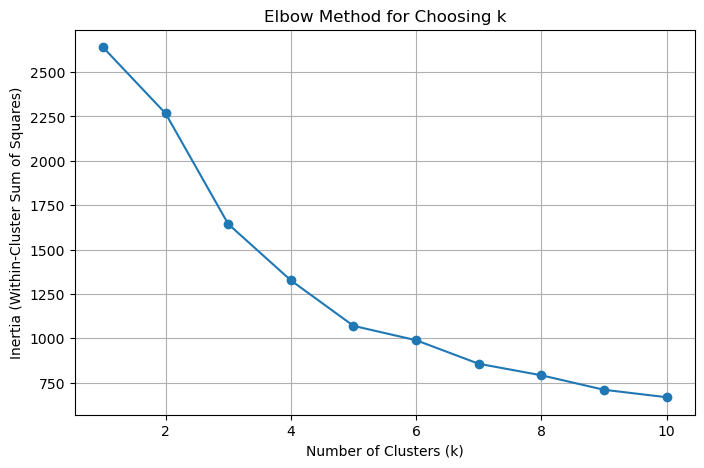

In [20]:
#Choose different values of k for the K-means algorithm.
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


df = pd.read_csv("Wholesale customers data.csv")
df = df.dropna()
df = df.drop(['Channel', 'Region'], axis=1)


# Scale data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


#  Try different k values

inertia_values = []
k_values = range(1, 11)   # k = 1 to 10

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia_values.append(kmeans.inertia_)


 
#  Plot the Elbow Curve

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, marker='o')
plt.title("Elbow Method for Choosing k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()


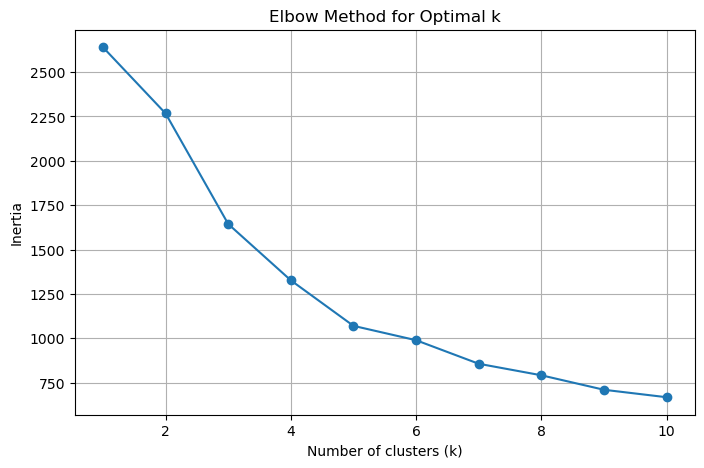

Based on the Elbow method, the best k is: 2


In [ ]:
#Try to visualize the elbow-curve and decide from it the best k and print it
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Wholesale customers data.csv")
df = df.dropna()
df = df.drop(['Channel', 'Region'], axis=1)


#Scale data

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


# Compute inertia for k=1 to 10

inertia_values = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia_values.append(kmeans.inertia_)


#  Plot Elbow Curve

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_values, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


# Find best k using the "Elbow" heuristic

# Simple approach: find k where the reduction in inertia slows down most
diff = np.diff(inertia_values)
diff2 = np.diff(diff)
best_k = np.argmin(diff2) + 2  # +2 because diff2 is offset by 2

print(f"Based on the Elbow method, the best k is: {best_k}")


In [ ]:
#different value for k
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


df = pd.read_csv("Wholesale customers data.csv")
df = df.dropna()
df = df.drop(['Channel', 'Region'], axis=1)


# Scale numeric features

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


#  Try different values of k and print inertia

k_values = range(1, 11)  # k from 1 to 10
inertia_values = []

print("K-Means clustering metrics:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia = kmeans.inertia_
    inertia_values.append(inertia)
    print(f"k = {k} -> Inertia = {inertia:.2f}")




K-Means clustering metrics:
k = 1 -> Inertia = 2640.00
k = 2 -> Inertia = 2266.96
k = 3 -> Inertia = 1644.06
k = 4 -> Inertia = 1326.67
k = 5 -> Inertia = 1070.26
k = 6 -> Inertia = 989.33
k = 7 -> Inertia = 856.71
k = 8 -> Inertia = 791.83
k = 9 -> Inertia = 710.19
k = 10 -> Inertia = 668.22


K-Means clustering metrics:
k = 1 -> Inertia = 2640.00
k = 2 -> Inertia = 2266.96
k = 3 -> Inertia = 1644.06
k = 4 -> Inertia = 1326.67
k = 5 -> Inertia = 1070.26


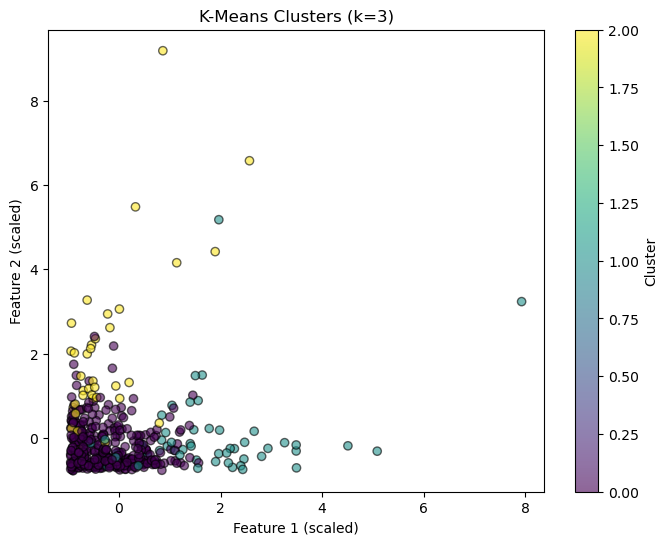

In [ ]:
#plotting clusters
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


df = pd.read_csv("Wholesale customers data.csv")
df = df.dropna()
df = df.drop(['Channel', 'Region'], axis=1)


#  Scale numeric features

scaler = StandardScaler()
X = scaler.fit_transform(df)  # X is a NumPy array


# Try different k values and print inertia

k_values = range(1, 6)  # you can adjust the range
print("K-Means clustering metrics:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    print(f"k = {k} -> Inertia = {kmeans.inertia_:.2f}")


#  Run K-Means with chosen k (e.g., k=3)

k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
clusters = kmeans.fit_predict(X)


# Plot clusters using first two features

plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis', edgecolors='k', alpha=0.6)
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.title(f'K-Means Clusters (k={k_optimal})')
plt.colorbar(label='Cluster')
plt.show()


In [27]:
import pandas as pd
df = pd.read_csv("Wholesale customers data.csv")
df = df.dropna()
df = df.drop(['Channel', 'Region'], axis=1)
from sklearn.datasets import load_iris
X, _ = load_iris(return_X_y=True)

    # Write your code here. Do not change any other parts of the code
from sklearn.cluster import AgglomerativeClustering

clusters = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X)
 



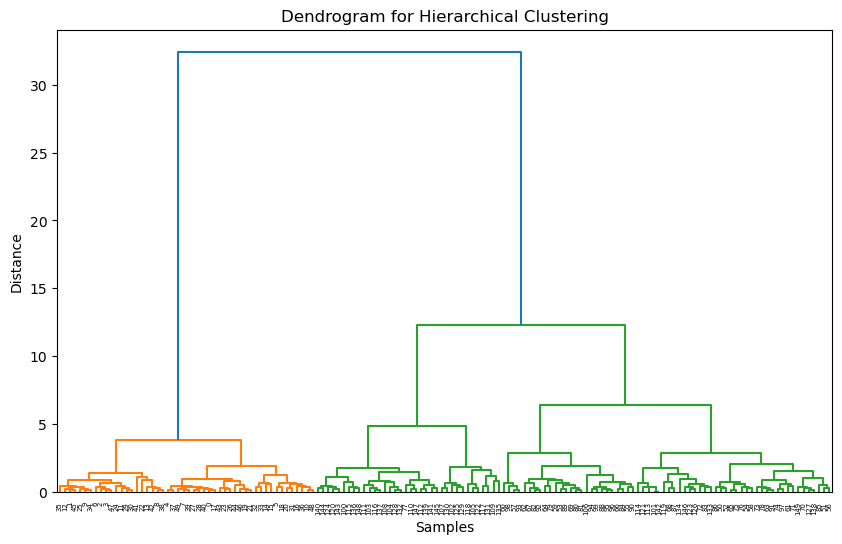

In [32]:
#dendrogram cluster

import pandas as pd 
df = pd.read_csv("Wholesale customers data.csv")
df = df.dropna()
df = df.drop(['Channel', 'Region'], axis=1)

#from sklearn.datasets import Wholesale_customers
#X, _ = Wholesale_customers(return_X_y=True)


# Dendrogram Code 
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


# Write your code here. Do not change any other parts of the code
from sklearn.cluster import AgglomerativeClustering

clusters = AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(X)


   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen  Cluster
0  12669  9656     7561     214              2674        1338        0
1   7057  9810     9568    1762              3293        1776        0
2   6353  8808     7684    2405              3516        7844        0
3  13265  1196     4221    6404               507        1788        0
4  22615  5410     7198    3915              1777        5185        1

Cluster counts:
Cluster
0    350
1     53
2     37
Name: count, dtype: int64


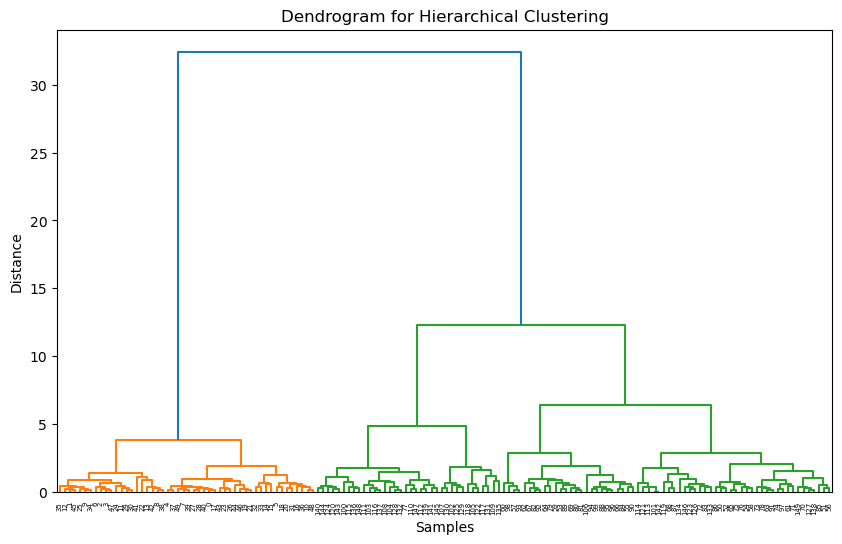

In [31]:
#Step 5 :Clustering Using K-Means
#Use a K-Means instance to cluster the data.
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


df = pd.read_csv("Wholesale customers data.csv")

# Drop NaN values
df = df.dropna()

# Drop categorical columns
df = df.drop(['Channel', 'Region'], axis=1)


#Scale numeric features

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Apply K-Means clustering

kmeans = KMeans(n_clusters=3, random_state=42)   # you can change number of clusters
kmeans.fit(scaled_data)

# Cluster labels
labels = kmeans.labels_

# Add cluster labels to DataFrame
df['Cluster'] = labels


#  Display results

print(df.head())
print("\nCluster counts:")
print(df['Cluster'].value_counts())


# Dendrogram Code 
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


# Write your code here. Do not change any other parts of the code
from sklearn.cluster import AgglomerativeClustering

clusters = AgglomerativeClustering(n_clusters=3, linkage='ward').fit_predict(X)


In [ ]:
import pandas as pd
df = pd.read_csv("Wholesale customers data.csv")

selected_X = df.iloc[:500, 1:3].values

from sklearn.preprocessing import OneHotEncoder
encoded_X = OneHotEncoder().fit_transform(selected_X).toarray()

# Write your code here. Do not change any other parts of the code
from sklearn.cluster import MeanShift
ms = MeanShift(bandwidth=1.0)
ms = MeanShift(bandwidth=0.5)
ms = MeanShift(bandwidth=5.0)

clusters = ms.fit_predict(encoded_X)

print(clusters[0:5])

[0 0 0 0 0]


In [11]:
import pandas as pd
df = pd.read_csv("Wholesale customers data.csv")

selected_X = df.iloc[:500, 1:3].values

from sklearn.preprocessing import OneHotEncoder
encoded_X = OneHotEncoder().fit_transform(selected_X).toarray()

# Write your code here. Do not change any other parts of the code
from sklearn.cluster import MeanShift
ms = MeanShift(bandwidth=0.5)


clusters = ms.fit_predict(encoded_X)
print(clusters[0:5])

[326 260 255 331 388]


In [12]:
import pandas as pd
df = pd.read_csv("Wholesale customers data.csv")

selected_X = df.iloc[:500, 1:3].values

from sklearn.preprocessing import OneHotEncoder
encoded_X = OneHotEncoder().fit_transform(selected_X).toarray()

# Write your code here. Do not change any other parts of the code
from sklearn.cluster import MeanShift

ms = MeanShift(bandwidth=5.0)

clusters = ms.fit_predict(encoded_X)
print(clusters[0:5])

[0 0 0 0 0]
